# LightGBM model tuning

## Import packages and data

In [30]:
import pandas as pd
import gc
import matplotlib.pyplot as plt
import optuna
import lightgbm as lgb

from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, precision_score, recall_score, ConfusionMatrixDisplay, roc_curve
from lightgbm.callback import early_stopping, log_evaluation
from optuna.visualization.matplotlib import (plot_slice, plot_param_importances, plot_optimization_history)

In [2]:
path_to_data = "~/PycharmProjects/home-credit-default-risk/data/processed/"
# path_to_data = "/content/drive/MyDrive/Home_Credit_data/"

application_train_df = pd.read_csv(path_to_data+"application_train.csv")
print(application_train_df.shape)
# application_test_df = pd.read_csv(path_to_data+"application_test.csv")

(307511, 722)


## Split into train and val

In [3]:
y = application_train_df.pop("TARGET")
application_train_df.pop("SK_ID_CURR")
X = application_train_df

In [4]:
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [5]:
del X
del application_train_df
gc.collect()

20

## Clear all special characters

In [6]:
import re

bad_cols = [col for col in X_train.columns if re.search(r'[\[\]\{\}"\:,]', str(col))]

print("Колонок с запрещёнными символами:", len(bad_cols))
print(bad_cols[:20])

Колонок с запрещёнными символами: 14
['PREV_NAME_TYPE_SUITE_Spouse, partner_COUNT', 'PREV_PRODUCT_COMBINATION_Cash Street: high_COUNT', 'PREV_PRODUCT_COMBINATION_Cash Street: low_COUNT', 'PREV_PRODUCT_COMBINATION_Cash Street: middle_COUNT', 'PREV_PRODUCT_COMBINATION_Cash X-Sell: high_COUNT', 'PREV_PRODUCT_COMBINATION_Cash X-Sell: low_COUNT', 'PREV_PRODUCT_COMBINATION_Cash X-Sell: middle_COUNT', 'PREV_NAME_TYPE_SUITE_Spouse, partner_SHARE', 'PREV_PRODUCT_COMBINATION_Cash Street: high_SHARE', 'PREV_PRODUCT_COMBINATION_Cash Street: low_SHARE', 'PREV_PRODUCT_COMBINATION_Cash Street: middle_SHARE', 'PREV_PRODUCT_COMBINATION_Cash X-Sell: high_SHARE', 'PREV_PRODUCT_COMBINATION_Cash X-Sell: low_SHARE', 'PREV_PRODUCT_COMBINATION_Cash X-Sell: middle_SHARE']


In [7]:
clean_cols = [
    re.sub(
        r'[^A-Za-z0-9_]+',
        '_',
        str(col)
    )
    for col in X_train.columns
]

print(
    "Дубликатов после очистки:",
    len(clean_cols) - len(set(clean_cols))
)

assert len(clean_cols) == len(set(clean_cols))

Дубликатов после очистки: 0


In [8]:
X_train.columns = clean_cols
X_val.columns = clean_cols

## Categorical features

In [9]:
cat_cols = X_train.select_dtypes(include = 'object').columns.tolist()
len(cat_cols)

16

In [10]:
for col in cat_cols:
    categories = X_train[col].dropna().unique()
    X_train[col] = pd.Categorical(X_train[col], categories = categories)
    X_val[col] = pd.Categorical(X_val[col], categories = categories)


In [11]:
X_train.select_dtypes(include='object').columns

Index([], dtype='object')

## LightGBM with optuna

We used the second model LightGBM based on the "application_train" features.

In [12]:
def objective_lgbm(trial):
    max_depth = trial.suggest_int("max_depth", 3, 10)
    num_leaves = trial.suggest_int("num_leaves", 8, min(2 ** max_depth, 128))
    learning_rate = trial.suggest_float("learning_rate", 0.01, 0.15, log=True)
    min_child_samples = trial.suggest_int("min_child_samples", 20, 200)
    min_split_gain = trial.suggest_float("min_split_gain", 0.0, 2.0)
    subsample = trial.suggest_float("subsample", 0.6, 1.0)
    colsample_bytree = trial.suggest_float("colsample_bytree", 0.5, 1.0)

    model = lgb.LGBMClassifier(
        objective="binary",
        n_estimators=3000,
        learning_rate=learning_rate,
        max_depth=max_depth,
        num_leaves=num_leaves,
        min_child_samples=min_child_samples,
        min_split_gain=min_split_gain,
        subsample=subsample,
        subsample_freq=1,
        colsample_bytree=colsample_bytree,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1,
        verbosity=-1
    )
    model.fit(X_train, y_train, eval_X=X_val, eval_y=y_val, eval_metric="auc", categorical_feature=cat_cols, callbacks=[early_stopping(stopping_rounds=100, first_metric_only=True, verbose=False), log_evaluation(0)])

    proba = model.predict_proba(X_val, num_iteration=model.best_iteration_)[:, 1]
    auc = roc_auc_score(y_val, proba)
    trial.set_user_attr("best_iteration", model.best_iteration_)

    return auc

In [13]:
study_lgbm_opt = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=42))
study_lgbm_opt.optimize(objective_lgbm, n_trials=50, show_progress_bar=True, n_jobs=1, gc_after_trial=True)

[I 2026-08-25 23:33:46,190] A new study created in memory with name: no-name-7b0ab0cd-2832-4497-9f26-8e643751625f


  0%|          | 0/50 [00:00<?, ?it/s]

[I 2026-08-25 23:34:08,733] Trial 0 finished with value: 0.7875374855941785 and parameters: {'max_depth': 5, 'num_leaves': 31, 'learning_rate': 0.07259248719561363, 'min_child_samples': 128, 'min_split_gain': 0.31203728088487304, 'subsample': 0.662397808134481, 'colsample_bytree': 0.5290418060840998}. Best is trial 0 with value: 0.7875374855941785.
[I 2026-08-25 23:34:41,755] Trial 1 finished with value: 0.7862047954842695 and parameters: {'max_depth': 9, 'num_leaves': 80, 'learning_rate': 0.06803900745073706, 'min_child_samples': 23, 'min_split_gain': 1.9398197043239886, 'subsample': 0.9329770563201687, 'colsample_bytree': 0.6061695553391381}. Best is trial 0 with value: 0.7875374855941785.
[I 2026-08-25 23:35:34,827] Trial 2 finished with value: 0.7895720893472106 and parameters: {'max_depth': 4, 'num_leaves': 9, 'learning_rate': 0.02279379523765072, 'min_child_samples': 114, 'min_split_gain': 0.8638900372842315, 'subsample': 0.7164916560792167, 'colsample_bytree': 0.8059264473611898

In [14]:
best_params_lgbm = study_lgbm_opt.best_params
best_params_lgbm

{'max_depth': 8,
 'num_leaves': 28,
 'learning_rate': 0.01892758558194398,
 'min_child_samples': 158,
 'min_split_gain': 0.24316006510323568,
 'subsample': 0.6700476512879127,
 'colsample_bytree': 0.5304132276074509}

In [15]:
best_val_lgbm = study_lgbm_opt.best_value
best_val_lgbm

0.7918697072154272

In [16]:
best_iteration_lgbm = (study_lgbm_opt.best_trial.user_attrs["best_iteration"])
print("Best iteration:", best_iteration_lgbm)

Best iteration: 1406


In [17]:
def objective_lgbm_stage2(trial):

    max_depth = trial.suggest_int(
        "max_depth",
        6,
        10
    )

    num_leaves = trial.suggest_int(
        "num_leaves",
        16,
        min(2 ** max_depth, 60)
    )

    learning_rate = trial.suggest_float(
        "learning_rate",
        0.01,
        0.04,
        log=True
    )

    min_child_samples = trial.suggest_int(
        "min_child_samples",
        100,
        220
    )

    min_split_gain = trial.suggest_float(
        "min_split_gain",
        0.0,
        0.8
    )

    subsample = trial.suggest_float(
        "subsample",
        0.55,
        0.80
    )

    colsample_bytree = trial.suggest_float(
        "colsample_bytree",
        0.35,
        0.70
    )

    model = lgb.LGBMClassifier(
        objective="binary",
        n_estimators=3000,
        learning_rate=learning_rate,
        max_depth=max_depth,
        num_leaves=num_leaves,
        min_child_samples=min_child_samples,
        min_split_gain=min_split_gain,
        subsample=subsample,
        subsample_freq=1,
        colsample_bytree=colsample_bytree,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1,
        verbosity=-1
    )

    model.fit(
        X_train,
        y_train,
        eval_X=X_val,
        eval_y=y_val,
        eval_metric="auc",
        categorical_feature=cat_cols,
        callbacks=[
            early_stopping(
                stopping_rounds=100,
                first_metric_only=True,
                verbose=False
            ),
            log_evaluation(0)
        ]
    )

    proba = model.predict_proba(
        X_val,
        num_iteration=model.best_iteration_
    )[:, 1]

    auc = roc_auc_score(
        y_val,
        proba
    )

    trial.set_user_attr(
        "best_iteration",
        model.best_iteration_
    )

    return auc

In [18]:
study_lgbm_stage2 = optuna.create_study(
    direction="maximize",
    sampler=optuna.samplers.TPESampler(seed=42)
)

study_lgbm_stage2.optimize(
    objective_lgbm_stage2,
    n_trials=50,
    show_progress_bar=True,
    n_jobs=1,
    gc_after_trial=True
)

[I 2026-08-26 01:03:47,229] A new study created in memory with name: no-name-80f8025e-1277-4198-aa9d-43dd0cfb947a


  0%|          | 0/50 [00:00<?, ?it/s]

[I 2026-08-26 01:04:32,866] Trial 0 finished with value: 0.7898523026354811 and parameters: {'max_depth': 7, 'num_leaves': 58, 'learning_rate': 0.027586986748117055, 'min_child_samples': 172, 'min_split_gain': 0.12481491235394922, 'subsample': 0.5889986300840507, 'colsample_bytree': 0.3703292642588698}. Best is trial 0 with value: 0.7898523026354811.
[I 2026-08-26 01:05:21,966] Trial 1 finished with value: 0.7910531882290257 and parameters: {'max_depth': 10, 'num_leaves': 43, 'learning_rate': 0.026687148364280117, 'min_child_samples': 102, 'min_split_gain': 0.7759278817295955, 'subsample': 0.7581106602001055, 'colsample_bytree': 0.42431868873739664}. Best is trial 1 with value: 0.7910531882290257.
[I 2026-08-26 01:06:52,739] Trial 2 finished with value: 0.7910621796774244 and parameters: {'max_depth': 6, 'num_leaves': 24, 'learning_rate': 0.015246567546835342, 'min_child_samples': 163, 'min_split_gain': 0.34555601491369264, 'subsample': 0.6228072850495106, 'colsample_bytree': 0.5641485

In [19]:
best_params_lgbm = study_lgbm_stage2.best_params
best_params_lgbm

{'max_depth': 10,
 'num_leaves': 30,
 'learning_rate': 0.015220942890410365,
 'min_child_samples': 194,
 'min_split_gain': 0.7038580548468286,
 'subsample': 0.5799009823000935,
 'colsample_bytree': 0.4311082776233844}

In [20]:
best_val_lgbm = study_lgbm_stage2.best_value
best_val_lgbm

0.7928588092878527

In [21]:
best_iteration_lgbm = (study_lgbm_stage2.best_trial.user_attrs["best_iteration"])
print("Best iteration-2:", best_iteration_lgbm)

Best iteration-2: 1925


In [22]:
%%time

lgbm_optuna = lgb.LGBMClassifier(
    objective = "binary",
    n_estimators = 3000,
    **study_lgbm_stage2.best_params,
    subsample_freq = 1,
    class_weight="balanced",
    random_state = 42,
    n_jobs = -1,
    verbosity = -1
)

lgbm_optuna.fit(X_train, y_train, eval_X=X_val, eval_y=y_val, eval_metric = "auc", categorical_feature=cat_cols, callbacks=[early_stopping(stopping_rounds=100, first_metric_only=True, verbose=False), log_evaluation(0)])
lgbm_optuna_proba = lgbm_optuna.predict_proba(X_val, num_iteration = lgbm_optuna.best_iteration_)[:, 1]
threshold = 0.5
lgbm_optuna_pred = (lgbm_optuna_proba >= threshold).astype(int)

lgbm_roc_auc_opt = roc_auc_score(y_val, lgbm_optuna_proba)
lgbm_precision_opt = precision_score(y_val, lgbm_optuna_pred, zero_division = 0)
lgbm_recall_opt = recall_score(y_val, lgbm_optuna_pred, zero_division = 0)

print("Лучшая итерация:", lgbm_optuna.best_iteration_)
print("ROC-AUC:", lgbm_roc_auc_opt)
print("Precision:", lgbm_precision_opt)
print("Recall:", lgbm_recall_opt)

Лучшая итерация: 1925
ROC-AUC: 0.7928588092878527
Precision: 0.20418815634126639
Recall: 0.6618328298086606
CPU times: user 17min 54s, sys: 24.6 s, total: 18min 18s
Wall time: 1min 39s


Text(0.5, 1.0, 'Confusion Matrix LightGBM')

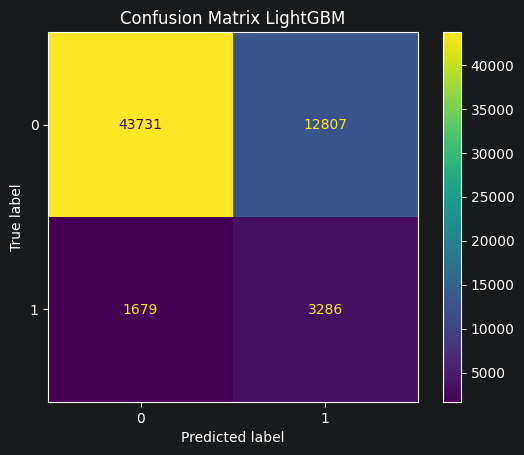

In [23]:
ConfusionMatrixDisplay.from_predictions(y_val, lgbm_optuna_pred)
plt.title("Confusion Matrix LightGBM")

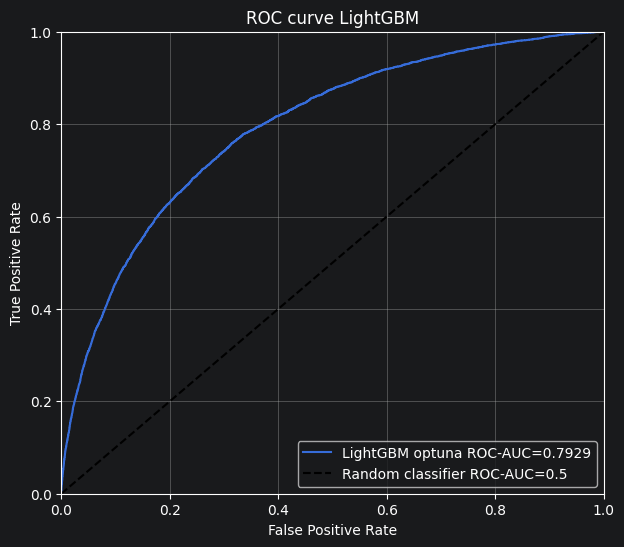

In [24]:
fpr, tpr, thresholds = roc_curve(y_val, lgbm_optuna_proba)
plt.figure(figsize=(7, 6))

plt.plot(fpr, tpr, label = f"LightGBM optuna ROC-AUC={lgbm_roc_auc_opt:.4f}")
plt.plot([0, 1], [0, 1], 'k--', label = "Random classifier ROC-AUC=0.5")
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.0])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC curve LightGBM")
plt.legend(loc="lower right")
plt.grid()

In [28]:
pip install plotly

Note: you may need to restart the kernel to use updated packages.


/tmp/ipykernel_174227/648757960.py:1: ExperimentalWarning: optuna.visualization.matplotlib._optimization_history.plot_optimization_history is experimental (supported from v2.2.0). The interface can change in the future.
  plot_optimization_history(study_lgbm_stage2)


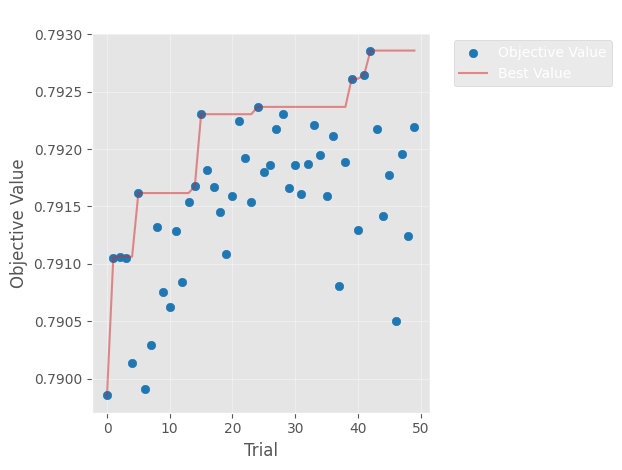

In [31]:
plot_optimization_history(study_lgbm_stage2)
plt.title("История оптимизации ROC-AUC")
plt.show()

/tmp/ipykernel_174227/1546626507.py:1: ExperimentalWarning: optuna.visualization.matplotlib._param_importances.plot_param_importances is experimental (supported from v2.2.0). The interface can change in the future.
  plot_param_importances(study_lgbm_stage2)


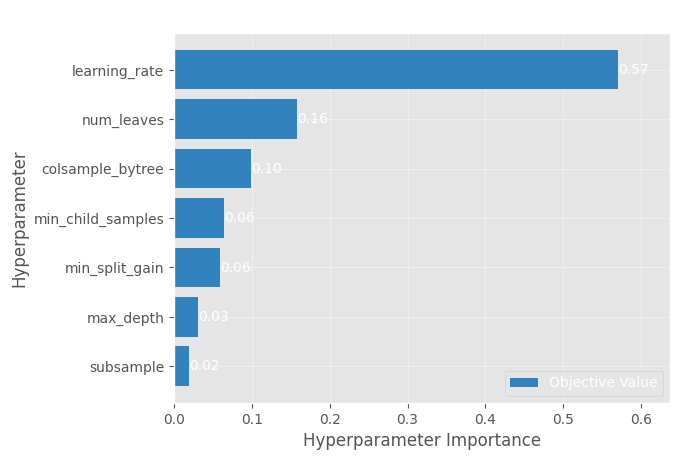

In [32]:
plot_param_importances(study_lgbm_stage2)
plt.title("Важность гиперпараметров")
plt.show()

/tmp/ipykernel_174227/3227438030.py:1: ExperimentalWarning: optuna.visualization.matplotlib._slice.plot_slice is experimental (supported from v2.2.0). The interface can change in the future.
  plot_slice(


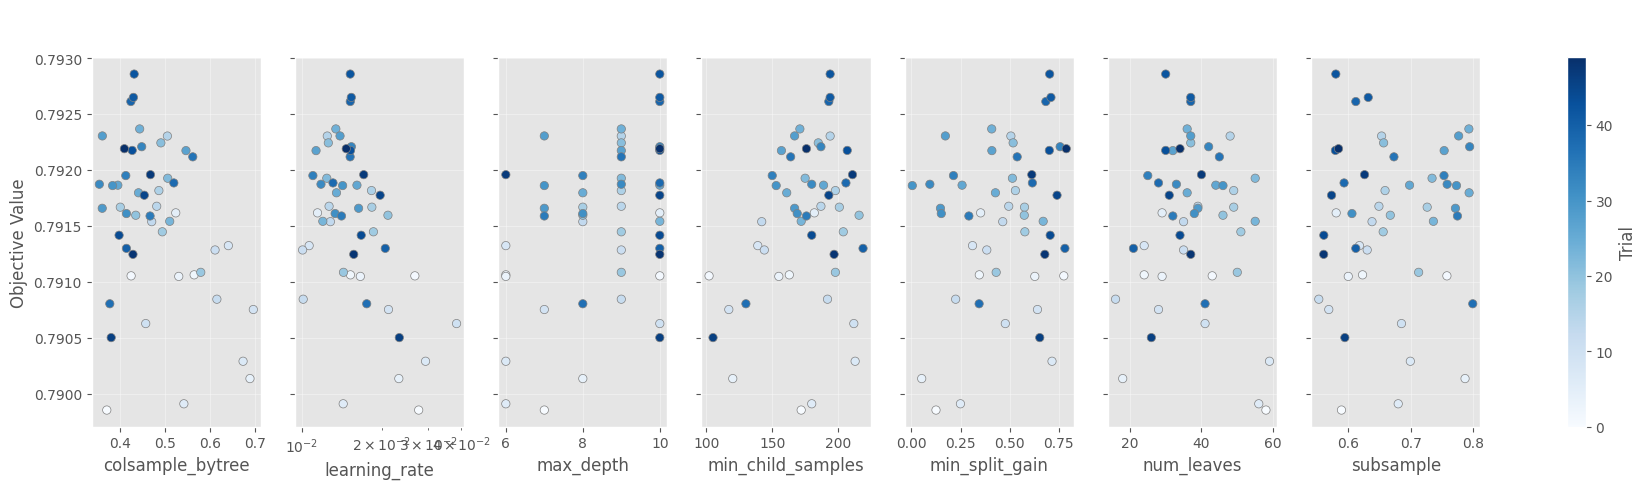

In [33]:
plot_slice(
    study_lgbm_stage2,
    params=[
        "max_depth",
        "num_leaves",
        "learning_rate",
        "min_child_samples",
        "min_split_gain",
        "subsample",
        "colsample_bytree"
    ]
)

plt.show()

## LightGBM without optuna

In [16]:
lgb_clf = lgb.LGBMClassifier(n_estimators=1000, max_depth=4, class_weight="balanced", learning_rate=0.1, random_state = 42, n_jobs=-1)
lgb_clf.fit(X_train, y_train, eval_set = [(X_val, y_val)], eval_metric='auc', categorical_feature=cat_cols, callbacks = [early_stopping(stopping_rounds=100), log_evaluation(period = 1)])

threshold = 0.5
val_pred_proba = lgb_clf.predict_proba(X_val)[:, 1]
val_pred = (val_pred_proba >= threshold).astype(int)


roc_auc_lgb = roc_auc_score(y_val, val_pred_proba)
prec_lgb = precision_score(y_val, val_pred, zero_division=0)
rec_lgb = recall_score(y_val, val_pred, zero_division=0)

print("Best_iteration:", lgb_clf.best_iteration_)
print("ROC-AUC_lgb:", roc_auc_lgb)
print("Precision_lgb:", prec_lgb)
print("Recall_lgb:", rec_lgb)

/home/usl/PycharmProjects/home-credit-default-risk/.venv/lib/python3.12/site-packages/lightgbm/sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


[LightGBM] [Info] Number of positive: 19876, number of negative: 226132
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.023001 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 11379
[LightGBM] [Info] Number of data points in the train set: 246008, number of used features: 115
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[1]	valid_0's auc: 0.702587	valid_0's binary_logloss: 0.680939
Training until validation scores don't improve for 100 rounds
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[2]	valid_0's auc: 0.710066	valid_0's binary_logloss: 0.670672
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[3]	valid_0's auc: 0.713546

Text(0.5, 1.0, 'Confusion Matrix LightGBM')

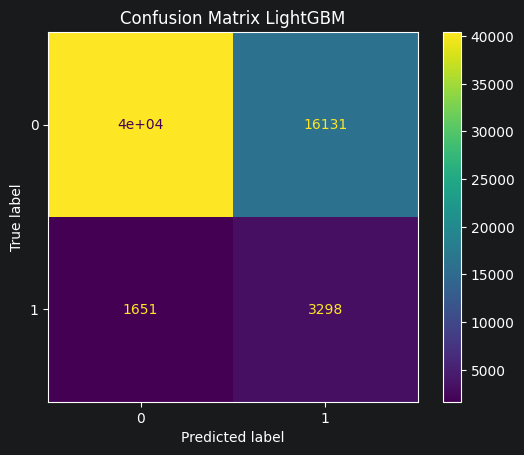

In [17]:
ConfusionMatrixDisplay.from_predictions(y_val, val_pred)
plt.title("Confusion Matrix LightGBM")

And now we will calculate the roc_curve and plot a graph:

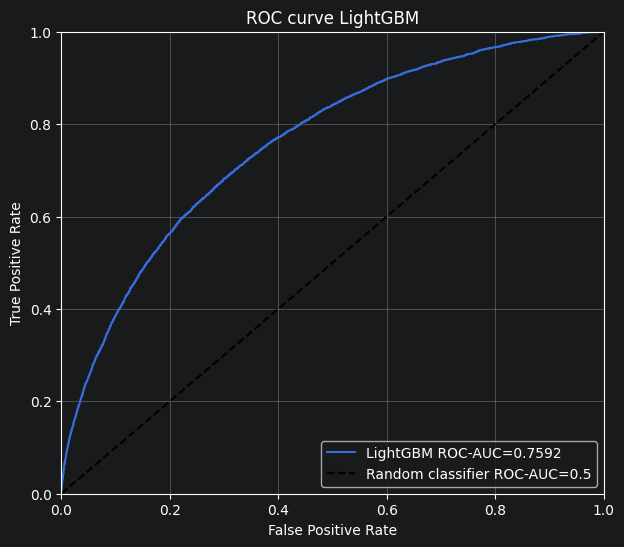

In [14]:
fpr, tpr, thresholds = roc_curve(y_val, val_pred_proba)
plt.figure(figsize=(7, 6))

plt.plot(fpr, tpr, label = f"LightGBM ROC-AUC={roc_auc_lgb:.4f}")
plt.plot([0, 1], [0, 1], 'k--', label = "Random classifier ROC-AUC=0.5")
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.0])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC curve LightGBM")
plt.legend(loc="lower right")
plt.grid()

We will prepare the test part for training:

In [15]:
application_test_df.shape

(48744, 120)

In [16]:
X_test = application_test_df

In [17]:
for col in cat_cols:
    X_test[col] = pd.Categorical(X_test[col], categories = X_train[col].cat.categories)
X_test.shape, X_train.shape

((48744, 120), (246008, 120))

In [18]:
list(X_train.columns) == list(X_test.columns)

True

In [19]:
test_pred_proba = lgb_clf.predict_proba(X_test)[:, 1]

In [20]:
submission = sample_submission_df.copy()
submission["TARGET"] = test_pred_proba
submission.head()

,SK_ID_CURR,TARGET
0,100001,0.041798
1,100005,0.141336
2,100013,0.039745
3,100028,0.039389
4,100038,0.147843


In [21]:
submission.shape, application_test_df.shape

((48744, 2), (48744, 120))

In [22]:
submission.to_csv("submission_lgb_baseline.csv", index=False)